In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from transformers import AutoTokenizer, AutoModelForCausalLM

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU : {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB\n")

Using device: cuda
GPU : Tesla T4
VRAM: 15.6 GB



In [3]:
MODEL_NAME = "Qwen/Qwen2.5-3B-Instruct"

print(f"Loading {MODEL_NAME} ...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if device.type == "cuda" else torch.float32,
    attn_implementation="eager",   # required for output_attentions=True
    trust_remote_code=True,
).to(device)
model.eval()

Loading Qwen/Qwen2.5-3B-Instruct ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 2048)
    (layers): ModuleList(
      (0-35): 36 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=True)
          (k_proj): Linear(in_features=2048, out_features=256, bias=True)
          (v_proj): Linear(in_features=2048, out_features=256, bias=True)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=2048, out_features=11008, bias=False)
          (up_proj): Linear(in_features=2048, out_features=11008, bias=False)
          (down_proj): Linear(in_features=11008, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((2048,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((2048,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((2048,), eps=1e-06)
    (ro

In [4]:
SYSTEM_PROMPT = (
    "You are a professional translator. "
    "Output ONLY the translated sentence. "
    "Do not explain, do not add notes, do not think out loud."
)

In [5]:
def build_prompt(text, src="English", tgt="French"):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": f"Translate from {src} to {tgt}:\n{text}"},
    ]

    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

In [6]:
def translate_with_attention(text, src="English", tgt="French"):
    prompt     = build_prompt(text, src, tgt)
    enc        = tokenizer(prompt, return_tensors="pt")
    input_ids  = enc["input_ids"].to(device)
    attn_mask  = enc["attention_mask"].to(device)
    prompt_len = input_ids.shape[1]

    # Locate idiom span inside prompt
    idiom_ids  = tokenizer(text, return_tensors="pt", add_special_tokens=False)["input_ids"][0]
    idiom_len  = len(idiom_ids)
    prompt_list = input_ids[0].tolist()
    idiom_list  = idiom_ids.tolist()
    idiom_start = None
    for i in range(len(prompt_list) - idiom_len, -1, -1):
        if prompt_list[i:i+idiom_len] == idiom_list:
            idiom_start = i
            break
    if idiom_start is None:
        idiom_start = max(0, prompt_len - idiom_len - 2)
    idiom_end = idiom_start + idiom_len

    with torch.no_grad():
        outputs = model.generate(
            input_ids,
            attention_mask=attn_mask,
            max_new_tokens=60,
            do_sample=False,
            return_dict_in_generate=True,
            output_attentions=True,
            pad_token_id=tokenizer.eos_token_id,
        )

    generated_ids = outputs.sequences[0][prompt_len:]
    translation   = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()

    # Build per-layer sliced attention (tgt_len, idiom_len)
    attentions = outputs.attentions
    num_layers = len(attentions[0])
    num_steps  = len(attentions)

    all_layers = []
    for layer_idx in range(num_layers):
        rows = []
        for step in range(num_steps):
            attn      = attentions[step][layer_idx]
            last_row  = attn[0].mean(dim=0)[-1]
            src_slice = last_row[idiom_start:idiom_end].cpu().float().numpy()
            rows.append(src_slice)
        all_layers.append(np.array(rows))

    attn_slice = all_layers[-1]

    # Full self-attention (last layer, last row per step)
    full_seq_len = outputs.sequences.shape[1]
    full_rows = []
    for step in range(num_steps):
        last_row = attentions[step][-1][0].mean(dim=0)[-1].cpu().float().numpy()
        padded   = np.zeros(full_seq_len)
        padded[:len(last_row)] = last_row
        full_rows.append(padded)
    full_attn = np.array(full_rows)

    def clean(tokens):
        out = []
        for t in tokens:
            if t in ["<|im_end|>", "<|endoftext|>", "<|im_start|>", ""]:
                continue
            t = t.replace("Ġ", " ").replace("▁", " ").strip()
            out.append(t if t else "·")
        return out

    src_tokens  = clean(tokenizer.convert_ids_to_tokens(idiom_ids))
    tgt_tokens  = clean(tokenizer.convert_ids_to_tokens(generated_ids))
    full_tokens = clean(tokenizer.convert_ids_to_tokens(outputs.sequences[0]))

    attn_slice = attn_slice[:len(tgt_tokens), :len(src_tokens)]
    all_layers = [l[:len(tgt_tokens), :len(src_tokens)] for l in all_layers]

    return translation, attn_slice, src_tokens, tgt_tokens, full_attn, full_tokens, all_layers

In [69]:
test_cases = [
    {"text": "It’s raining cats and dogs outside, and the streets are already flooded", "src": "English", "tgt": "French"},
    {"text": "Holy cow! I didn’t expect you to finish that marathon in under three hours.", "src": "English", "tgt": "French"},
    {"text": "My grandfather finally kicked the bucket last night.", "src": "English", "tgt": "French"},
    {"text": "It’s raining a lot, and the cats and dogs are all wet.", "src": "English", "tgt": "French"},
    {"text": "The villagers were amazed to see a cow tied to the church bell tower, truly a holy cow.", "src": "English", "tgt": "French"},
    {"text": "The kid tried to kick the bucket across the floor for fun.", "src": "English", "tgt": "French"},
]

In [70]:
cmap_en  = LinearSegmentedColormap.from_list("en",   ["#0d0d0d", "#ff3366", "#ffcc00"])
cmap_fr  = LinearSegmentedColormap.from_list("fr",   ["#0d0d0d", "#4a90e2", "#00f0ff"])
cmap_full = LinearSegmentedColormap.from_list("full", ["#0d0d0d", "#7b2fff", "#f15bb5", "#ffffff"])

results = []

for case in test_cases:
    print(f"{case['text']}")
    translation, attn_slice, src_tok, tgt_tok, full_attn, full_tok, all_layers = \
        translate_with_attention(case["text"], case["src"], case["tgt"])
    case.update({
        "translation": translation,
        "attn_slice":  attn_slice,
        "src_tok":     src_tok,
        "tgt_tok":     tgt_tok,
        "full_attn":   full_attn,
        "full_tok":    full_tok,
        "all_layers":  all_layers,
    })
    print(f"  → {translation}\n")
    results.append(case)

It’s raining cats and dogs outside, and the streets are already flooded
  → Il pleut des cordes dehors et les rues sont déjà inondées.

Holy cow! I didn’t expect you to finish that marathon in under three hours.
  → Ahou ! Je ne m’attendais pas que tu finisses ce marathon en moins de trois heures.

My grandfather finally kicked the bucket last night.
  → Mon grand-père est finalement décédé la nuit dernière.

It’s raining a lot, and the cats and dogs are all wet.
  → Il pleut beaucoup et tous les chats et toutous sont mouillés.

The villagers were amazed to see a cow tied to the church bell tower, truly a holy cow.
  → Les villageois étaient ébahis de voir une vache attachée au clocher de l'église, vraiment une bêche sainte.

The kid tried to kick the bucket across the floor for fun.
  → L'enfant a essayé de sauter par-dessus le rebord du bassin pour faire plaisir.



In [71]:
def normalize_rows(matrix):
    m = np.nan_to_num(matrix.copy().astype(float), nan=0.0, posinf=0.0, neginf=0.0)
    s = m.sum(axis=1, keepdims=True)
    s[s == 0] = 1
    return m / s

def safe_alpha(val):
    if np.isnan(val) or np.isinf(val):
        return 0.0
    return float(np.clip(val, 0.0, 1.0))

def plot_heatmap(attn, src_tokens, tgt_tokens, title, ax, cmap):
    h = min(attn.shape[0], len(tgt_tokens))
    w = min(attn.shape[1], len(src_tokens))
    matrix = normalize_rows(attn[:h, :w])
    ax.set_facecolor("#111111")
    ax.imshow(matrix, cmap=cmap, aspect="auto", vmin=0, vmax=1)
    ax.set_xticks(range(w))
    ax.set_xticklabels(src_tokens[:w], rotation=45, ha="right", fontsize=7.5, color="white")
    ax.set_yticks(range(h))
    ax.set_yticklabels(tgt_tokens[:h], fontsize=7.5, color="white")
    ax.set_xlabel("Source tokens", fontsize=8, color="#aaaaaa", labelpad=6)
    ax.set_ylabel("Translation tokens", fontsize=8, color="#aaaaaa", labelpad=6)
    ax.set_title(title, fontsize=9, fontweight="bold", pad=8, color="white")
    ax.tick_params(colors="white")
    for spine in ax.spines.values():
        spine.set_edgecolor("#444444")
        spine.set_linewidth(1.5)

def plot_arcs(attn, src_tokens, tgt_tokens, title, ax, color):
    h = min(attn.shape[0], len(tgt_tokens))
    w = min(attn.shape[1], len(src_tokens))
    matrix = normalize_rows(attn[:h, :w])
    span = max(w, h, 1)
    ax.set_xlim(-1, span)
    ax.set_ylim(-0.5, 1.5)
    ax.axis("off")
    ax.set_facecolor("#0a0a0a")
    ax.set_title(title, fontsize=9, fontweight="bold", pad=8, color="white")
    src_x = np.linspace(0, span - 1, max(w, 1))
    tgt_x = np.linspace(0, span - 1, max(h, 1))
    for ti in range(h):
        for si in range(w):
            weight = float(matrix[ti, si])
            if np.isnan(weight) or weight < 0.12:
                continue
            ax.annotate("",
                xy=(tgt_x[ti], 1.0), xytext=(src_x[si], 0.0),
                arrowprops=dict(
                    arrowstyle="-", color=color,
                    alpha=safe_alpha(weight * 1.5),
                    lw=float(np.clip(weight * 5, 0.1, 5.0)),
                    connectionstyle="arc3,rad=0.35"
                )
            )
    for i, tok in enumerate(src_tokens[:w]):
        ax.text(src_x[i], -0.15, tok, ha="center", va="top",
                fontsize=7, color="#cccccc", rotation=35)
    for i, tok in enumerate(tgt_tokens[:h]):
        ax.text(tgt_x[i], 1.15, tok, ha="center", va="bottom",
                fontsize=7, color="white", rotation=35)
    ax.text(-0.8, 0.0, "SRC", fontsize=8, color="#888888", va="center", style="italic")
    ax.text(-0.8, 1.0, "TGT", fontsize=8, color="white",   va="center", style="italic")

def plot_entropy_bars(attn, tgt_tokens, title, ax, color):
    h = min(attn.shape[0], len(tgt_tokens))
    matrix = normalize_rows(attn[:h])

    eps = 1e-9
    entropy = -np.sum(matrix * np.log(matrix + eps), axis=1)
    max_entropy = np.log(matrix.shape[1] + eps)
    entropy_norm = np.clip(entropy / max_entropy, 0, 1)

    tokens = tgt_tokens[:h]
    x = np.arange(len(tokens))

    # Color: green = focused (low entropy), red = diffuse (high entropy)
    bar_colors = plt.cm.RdYlGn_r(entropy_norm)

    ax.set_facecolor("#111111")
    bars = ax.bar(x, entropy, color=bar_colors, width=0.7,
                  edgecolor="#222222", linewidth=0.5)

    # Reference line: max possible entropy
    ax.axhline(max_entropy, color="white", linewidth=0.8,
               linestyle="--", alpha=0.25, label="max entropy")

    ax.set_xticks(x)
    ax.set_xticklabels(tokens, rotation=45, ha="right", fontsize=7.5, color="white")
    ax.set_ylabel("Entropy (nats)", fontsize=8, color="#aaaaaa", labelpad=6)
    ax.set_xlabel("Generated tokens", fontsize=8, color="#aaaaaa", labelpad=6)
    ax.set_title(title, fontsize=9, fontweight="bold", pad=8, color="white")
    ax.tick_params(colors="white")
    ax.set_ylim(0, max_entropy * 1.2)

    # Value labels on bars
    for bar, val in zip(bars, entropy):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max_entropy * 0.02,
                f"{val:.2f}", ha="center", va="bottom",
                fontsize=6, color="#aaaaaa")

    for spine in ax.spines.values():
        spine.set_edgecolor("#333333")
        spine.set_linewidth(1.0)

    # Legend
    ax.text(0.99, 0.97, "■ focused (low)",
            transform=ax.transAxes, fontsize=7,
            color="#44cc44", ha="right", va="top")
    ax.text(0.99, 0.88, "■ diffuse (high)",
            transform=ax.transAxes, fontsize=7,
            color="#ff4444", ha="right", va="top")


def plot_layer_evolution(all_layers, src_tokens, tgt_tokens, title):
    n_layers = len(all_layers)
    cols = 6
    rows = (n_layers + cols - 1) // cols
    cmap = LinearSegmentedColormap.from_list(
        "layer", ["#0a0a0a", "#9b5de5", "#f15bb5", "#fee440"])
    fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*3), facecolor="#0a0a0a")
    axes = axes.flatten()
    for i, layer_attn in enumerate(all_layers):
        ax = axes[i]
        ax.set_facecolor("#111111")
        h = min(layer_attn.shape[0], len(tgt_tokens))
        w = min(layer_attn.shape[1], len(src_tokens))
        ax.imshow(np.nan_to_num(layer_attn[:h, :w]), cmap=cmap, aspect="auto")
        ax.set_title(f"Layer {i+1}", fontsize=8, color="white")
        ax.axis("off")
    for i in range(n_layers, len(axes)):
        axes[i].axis("off")
    fig.suptitle(f"Layer Evolution — {title}", fontsize=11, color="white", fontweight="bold")
    plt.tight_layout(pad=1.5)
    plt.show()

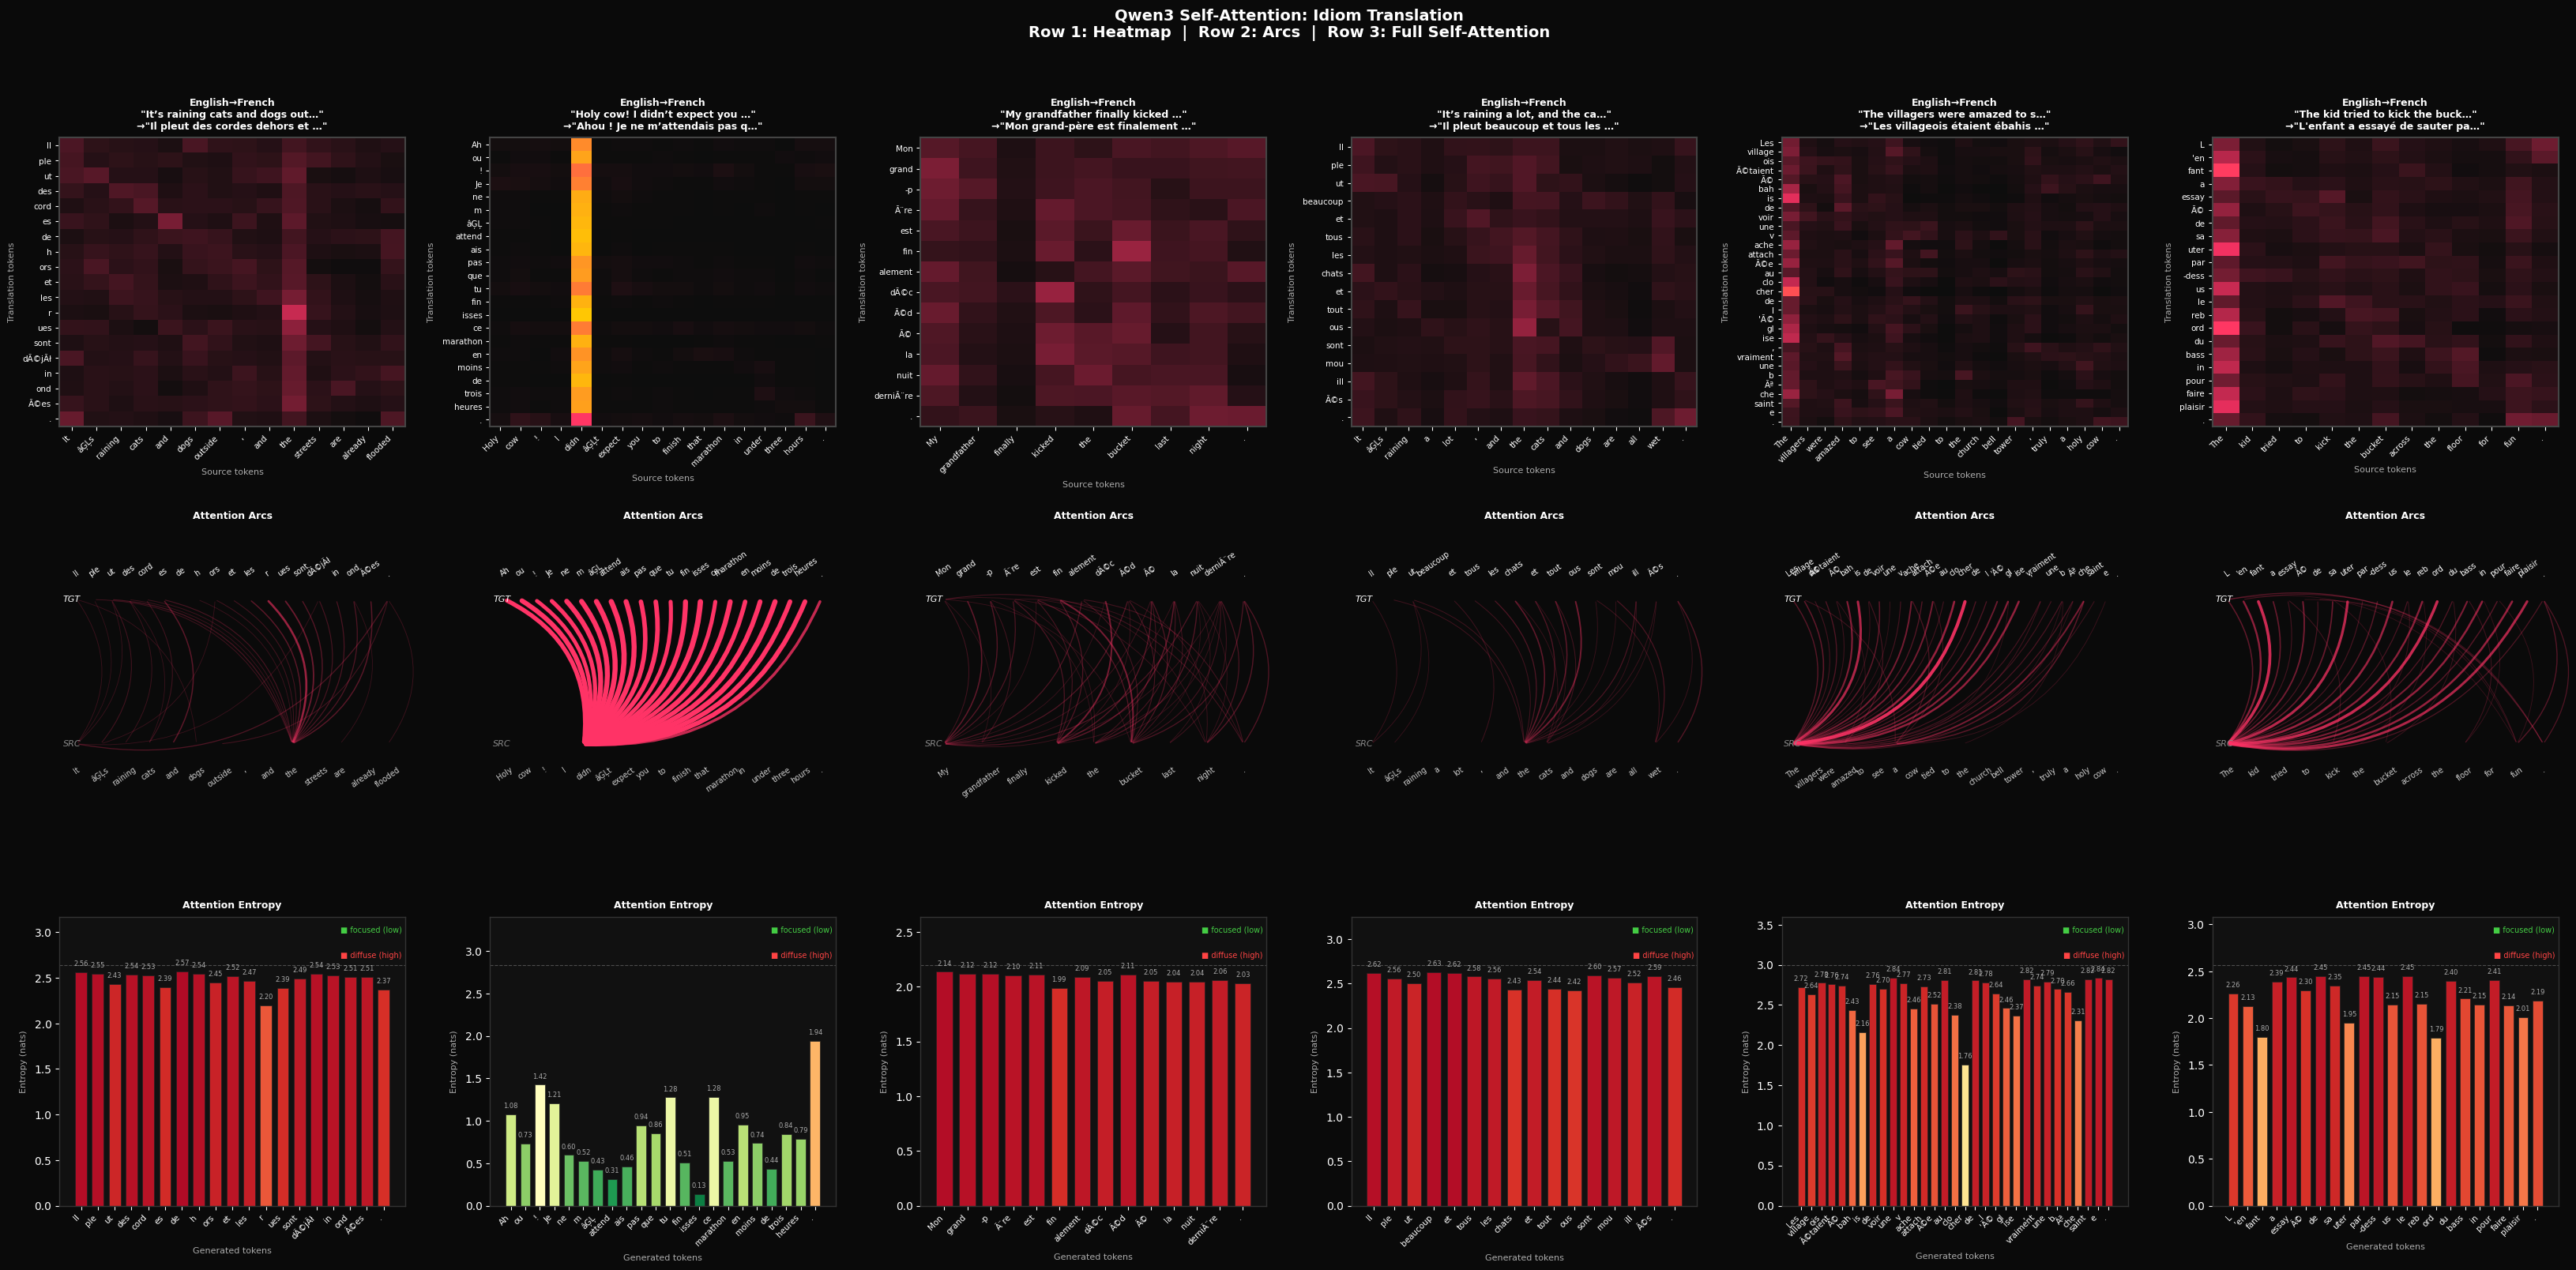

In [72]:
plt.rcParams.update({
    "text.color": "white", "axes.labelcolor": "white",
    "xtick.color": "white", "ytick.color": "white",
    "figure.facecolor": "#0a0a0a", "axes.facecolor": "#111111",
})

n = len(results)
fig, axes = plt.subplots(3, n, figsize=(5.5 * n, 16), facecolor="#0a0a0a")

fig.suptitle(
    "Qwen3 Self-Attention: Idiom Translation\n"
    "Row 1: Heatmap  |  Row 2: Arcs  |  Row 3: Full Self-Attention",
    fontsize=14, color="white", fontweight="bold", y=1.01
)

for col, case in enumerate(results):
    cmap  = cmap_en if case["src"] == "English" else cmap_fr
    color = "#ff3366" if case["src"] == "English" else "#4a90e2"
    short_src = case["text"][:30] + ("…" if len(case["text"]) > 30 else "")
    short_tgt = case["translation"][:30] + ("…" if len(case["translation"]) > 30 else "")
    title = f"{case['src']}→{case['tgt']}\n\"{short_src}\"\n→\"{short_tgt}\""

    plot_heatmap(case["attn_slice"], case["src_tok"], case["tgt_tok"],
                 title, axes[0][col], cmap)
    plot_arcs(case["attn_slice"], case["src_tok"], case["tgt_tok"],
              "Attention Arcs", axes[1][col], color)
    plot_entropy_bars(case["attn_slice"], case["tgt_tok"],
                      "Attention Entropy", axes[2][col], color)

plt.tight_layout(pad=2.0)
plt.show()

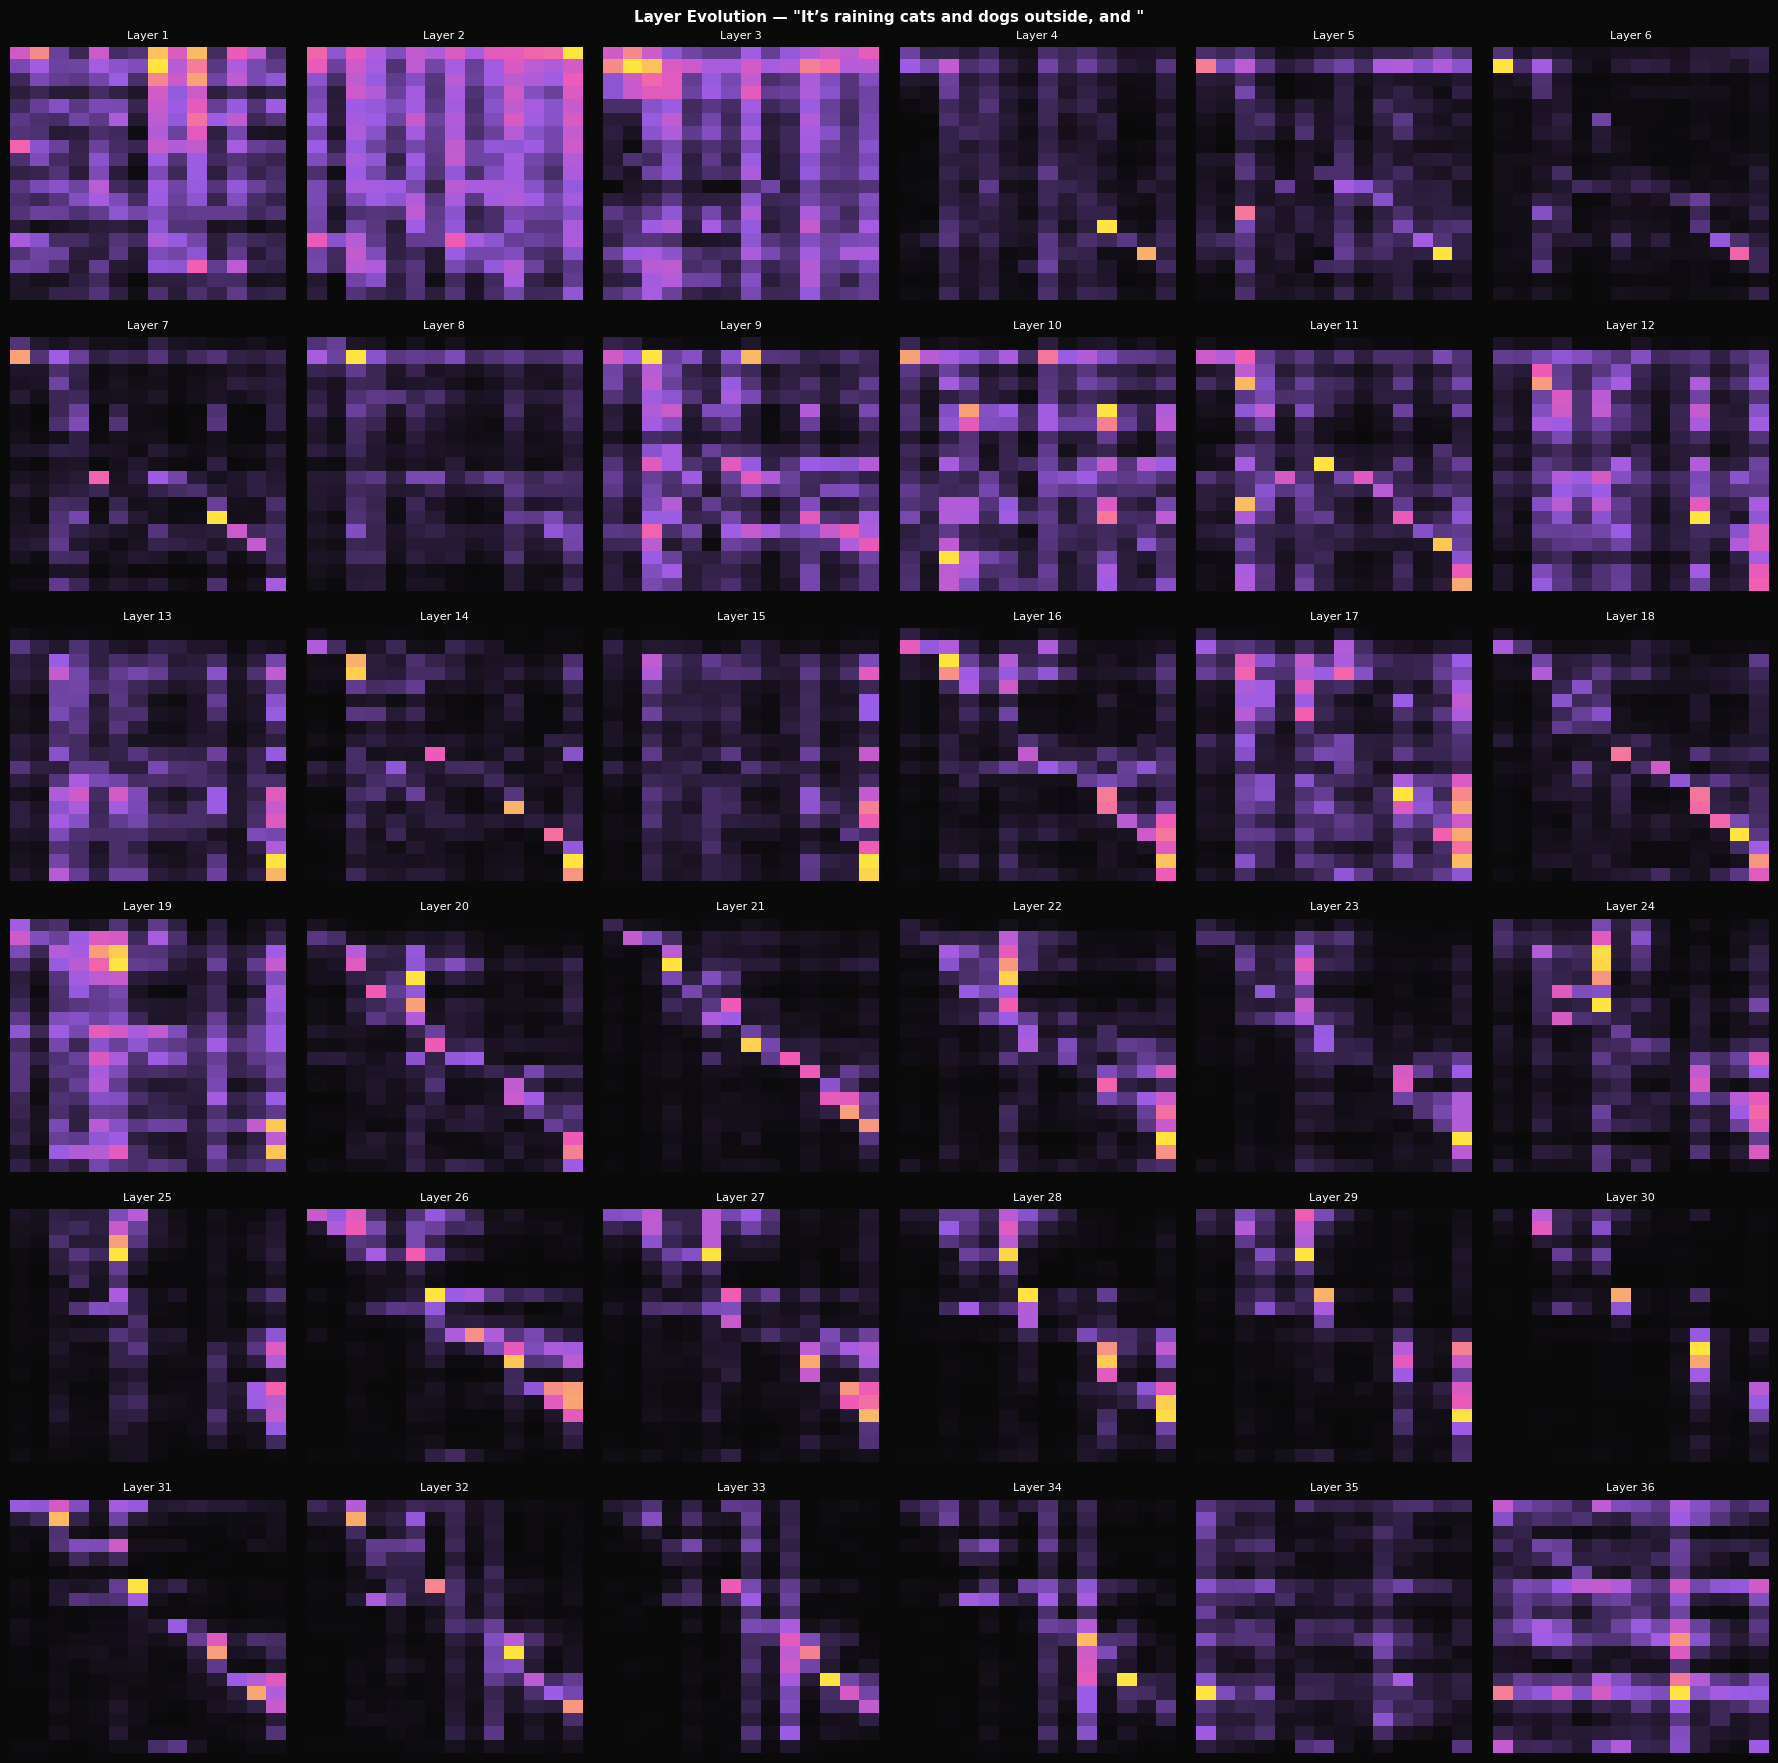

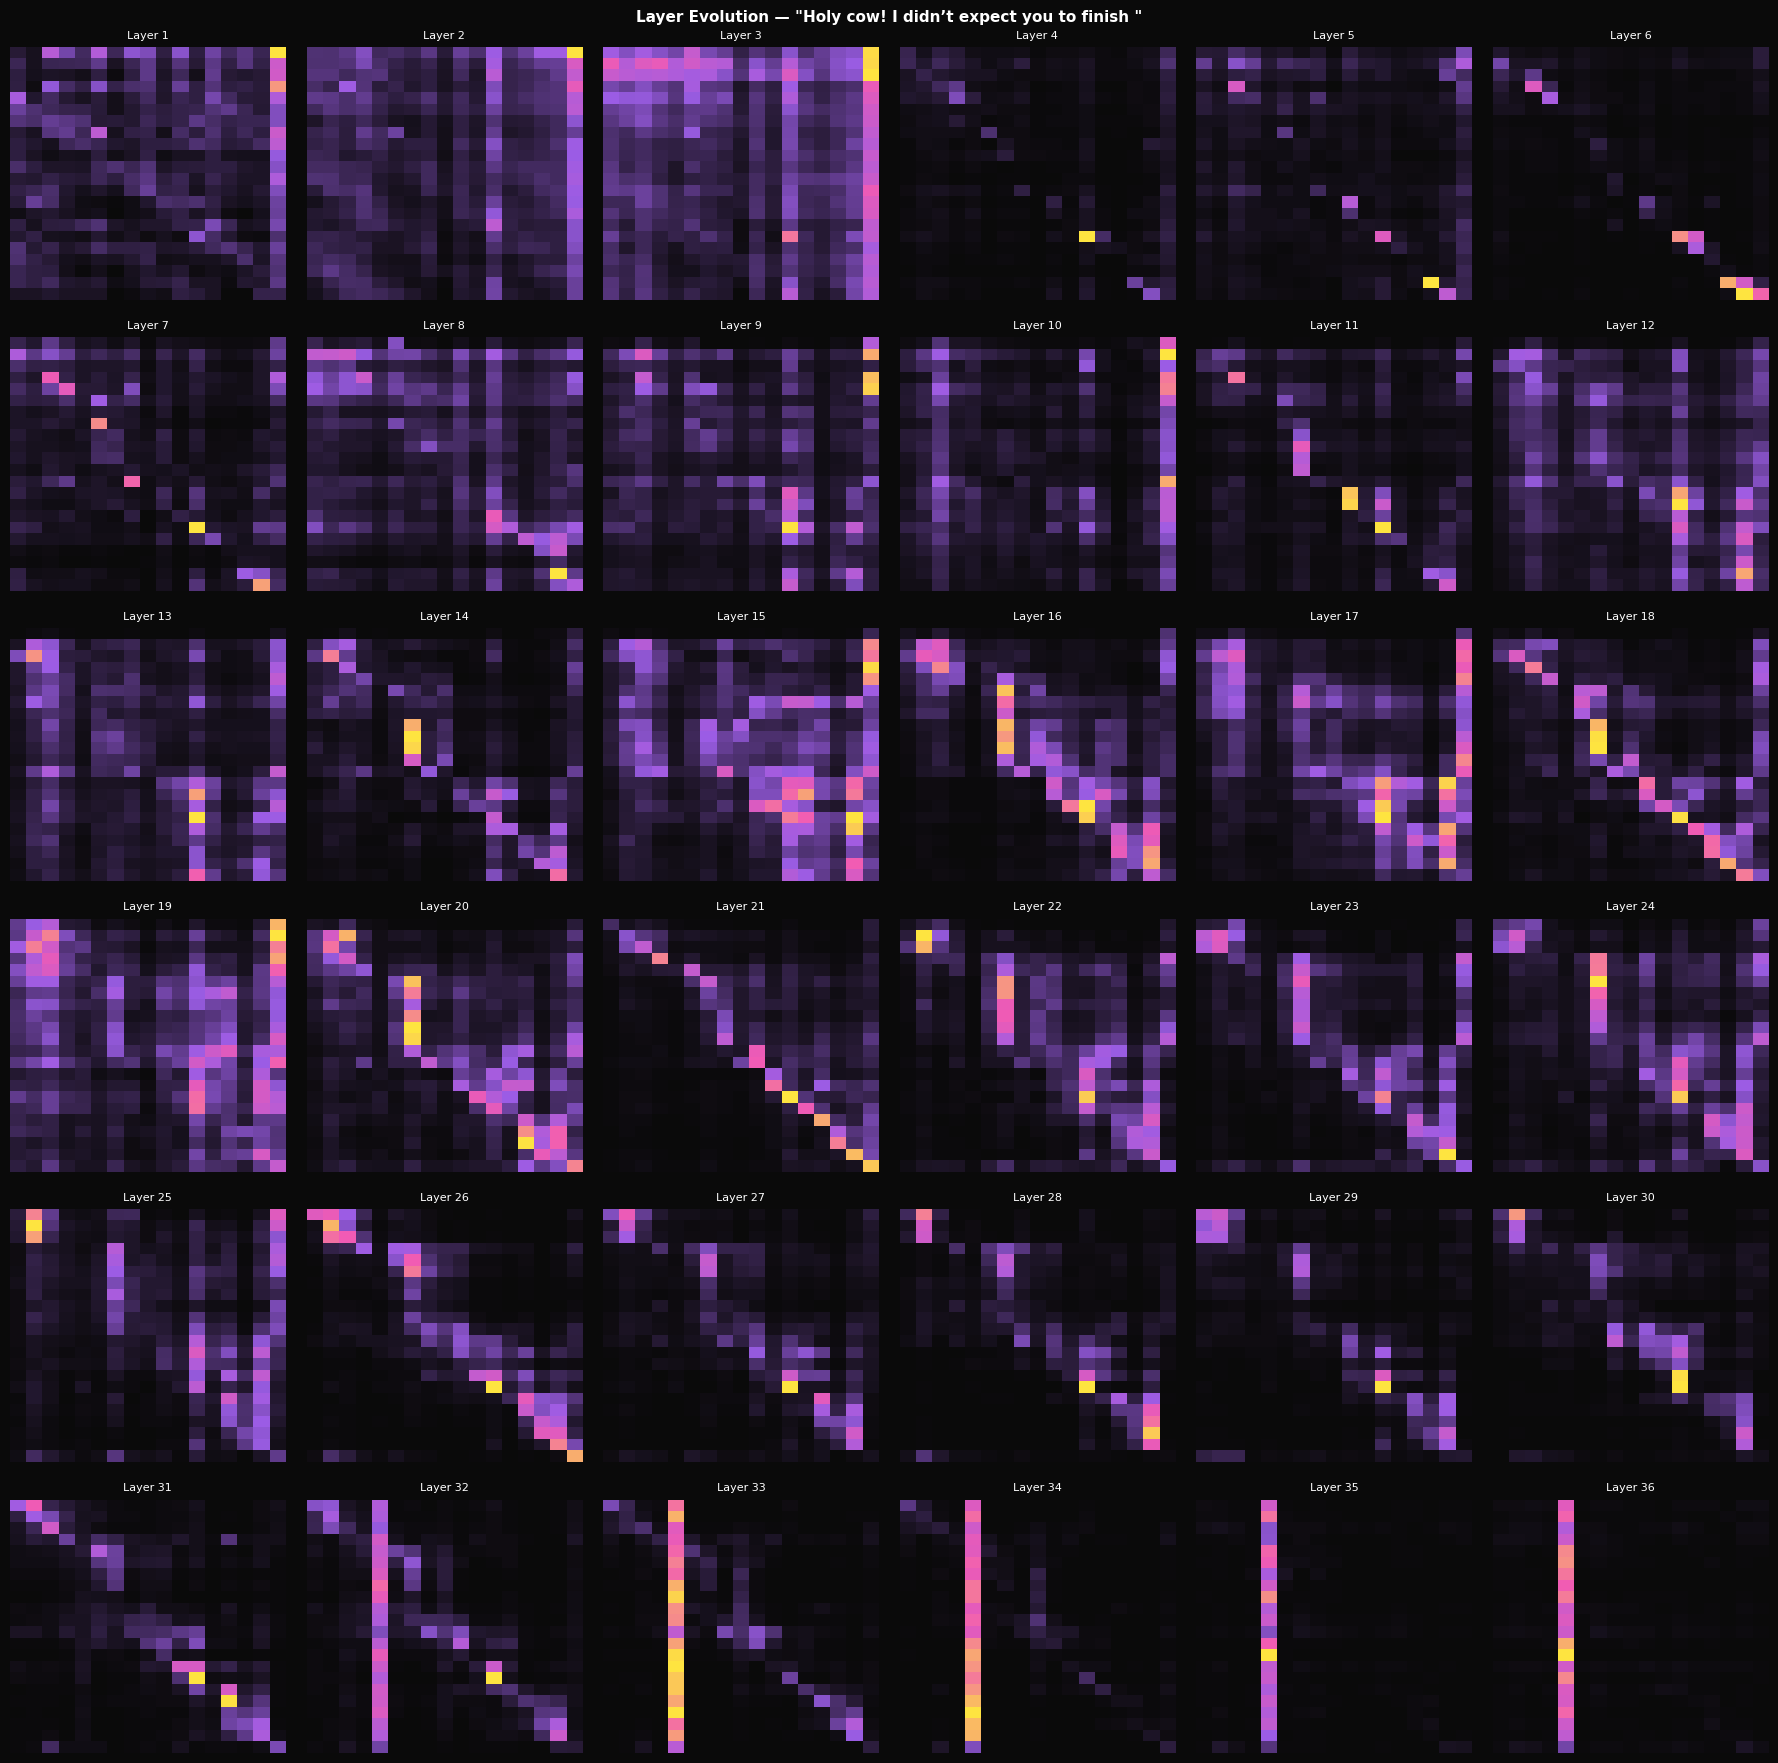

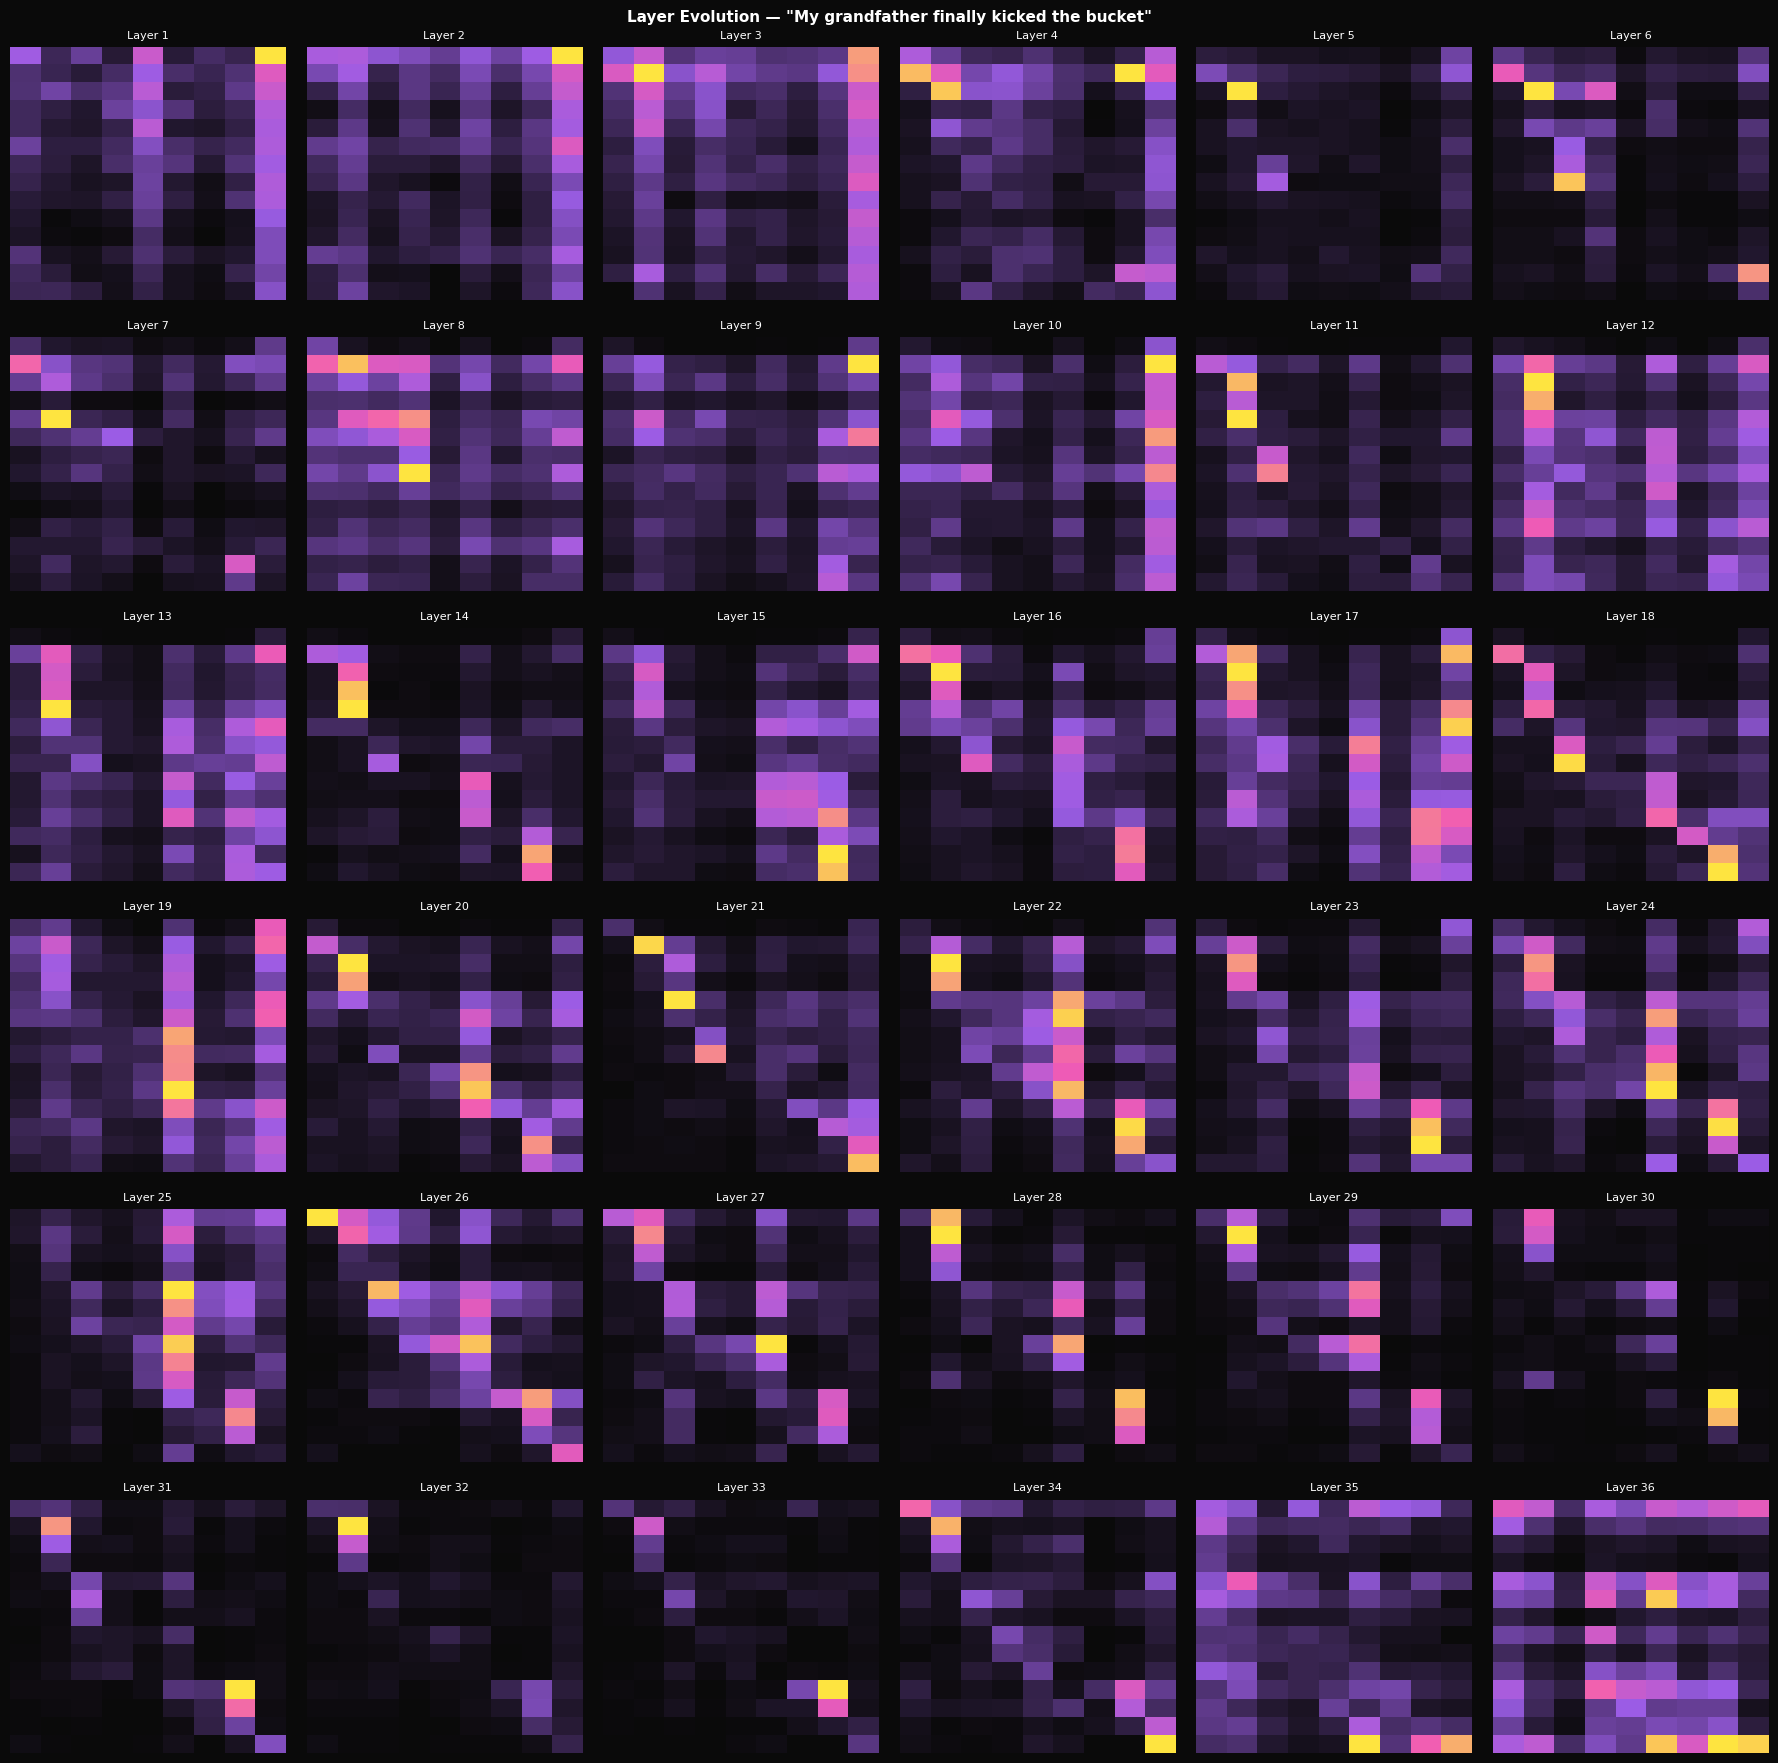

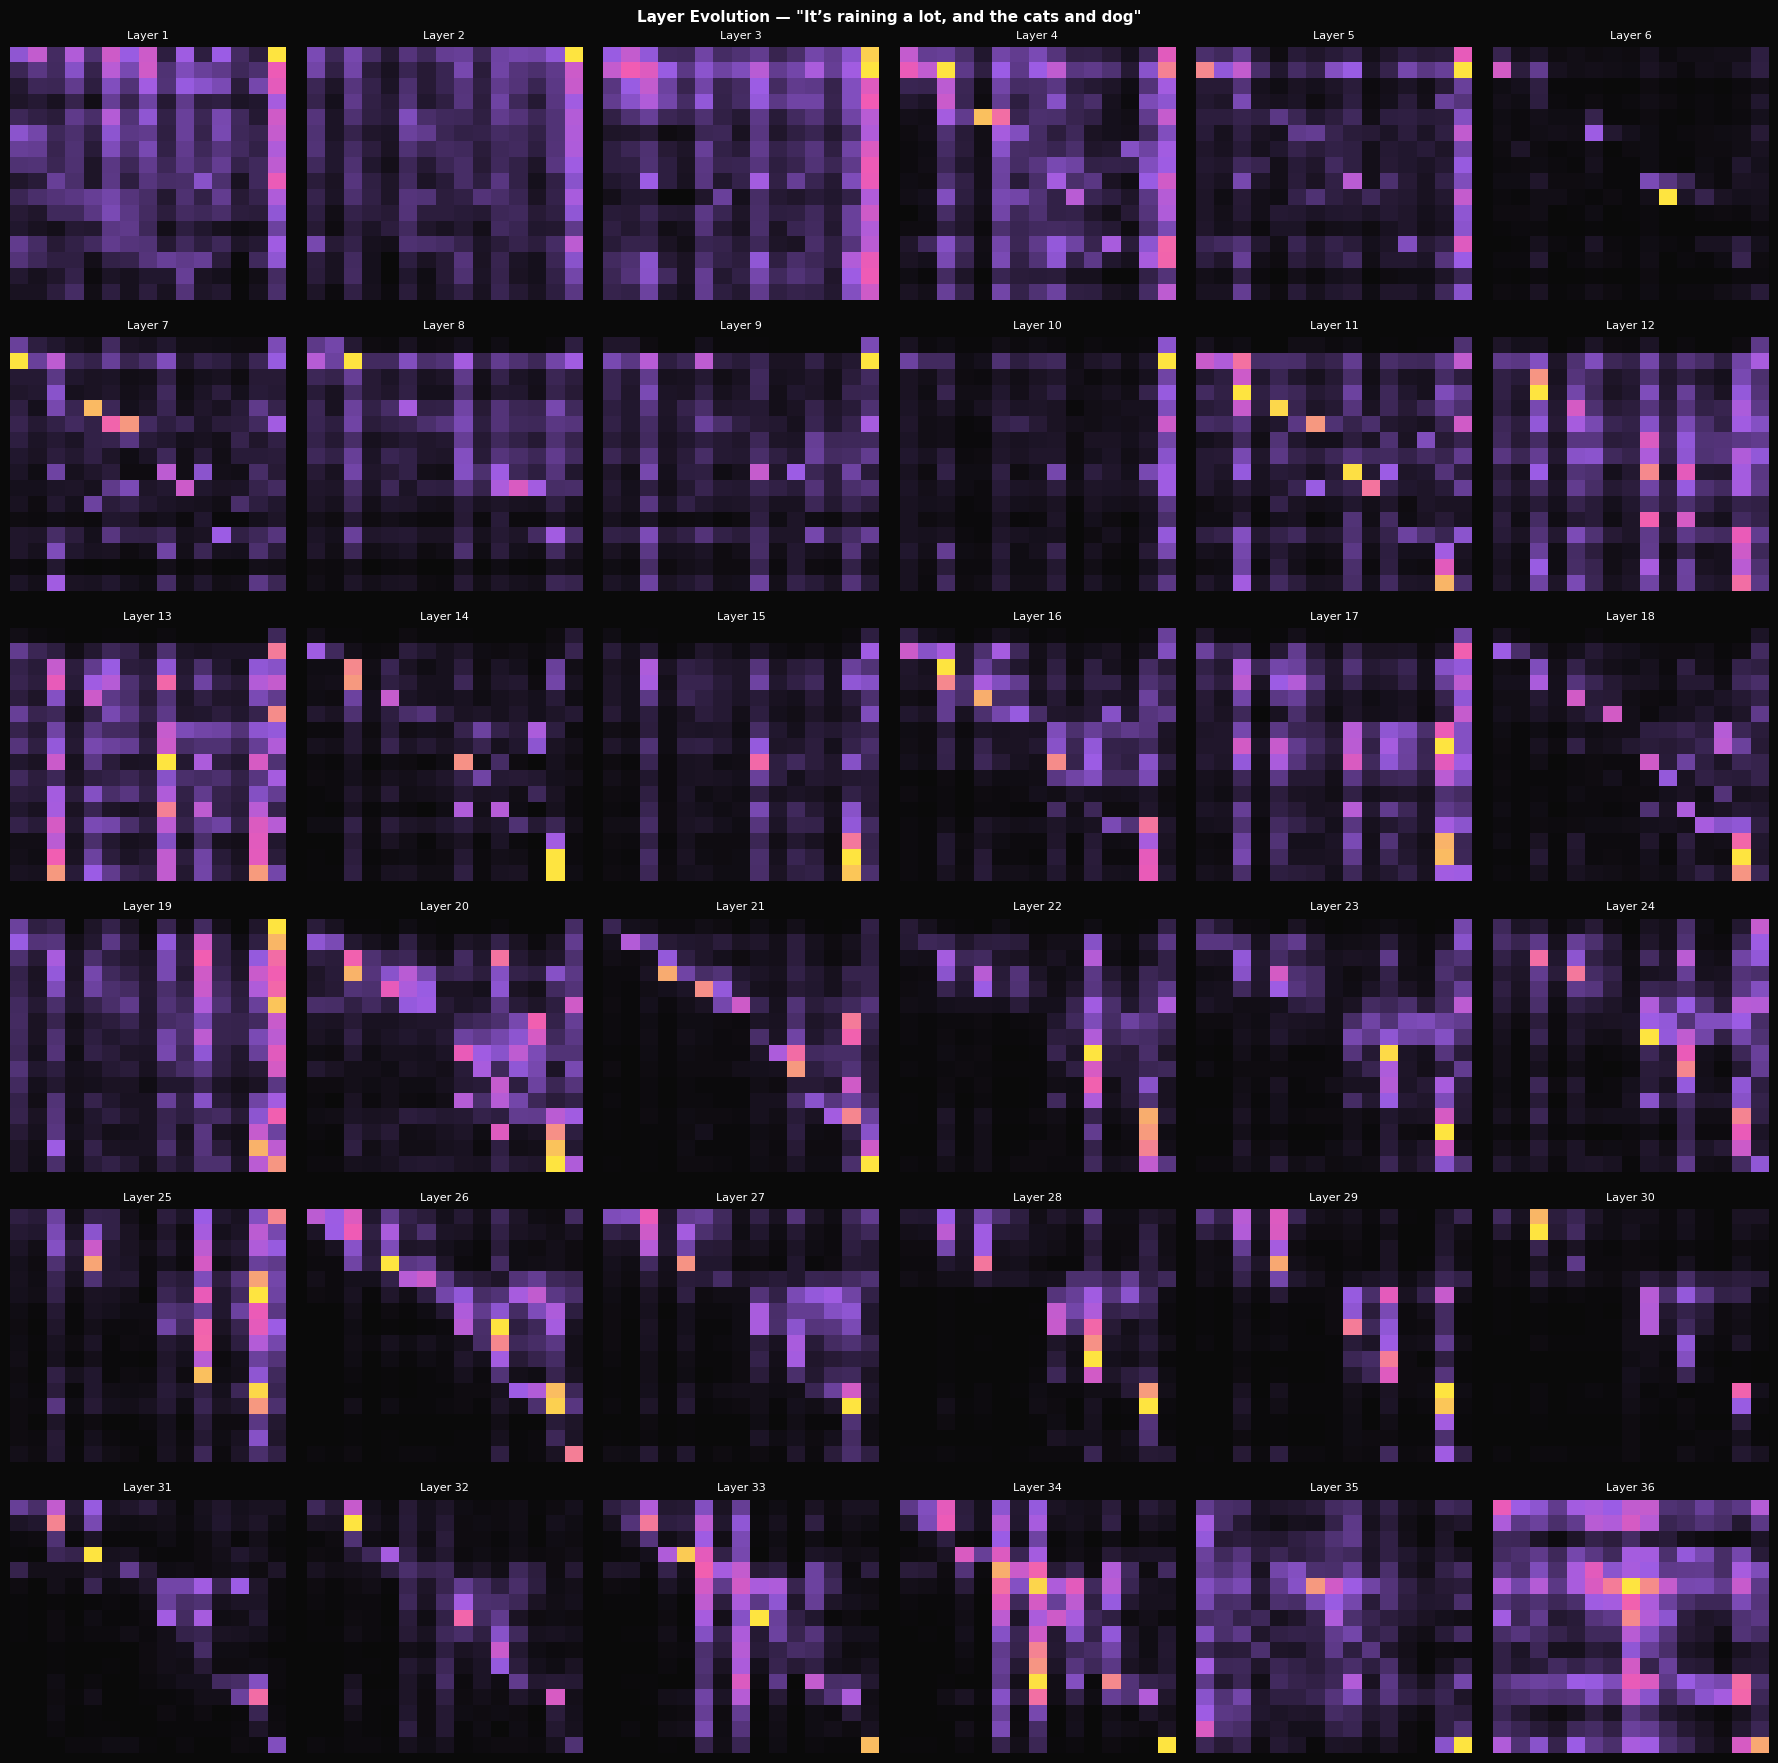

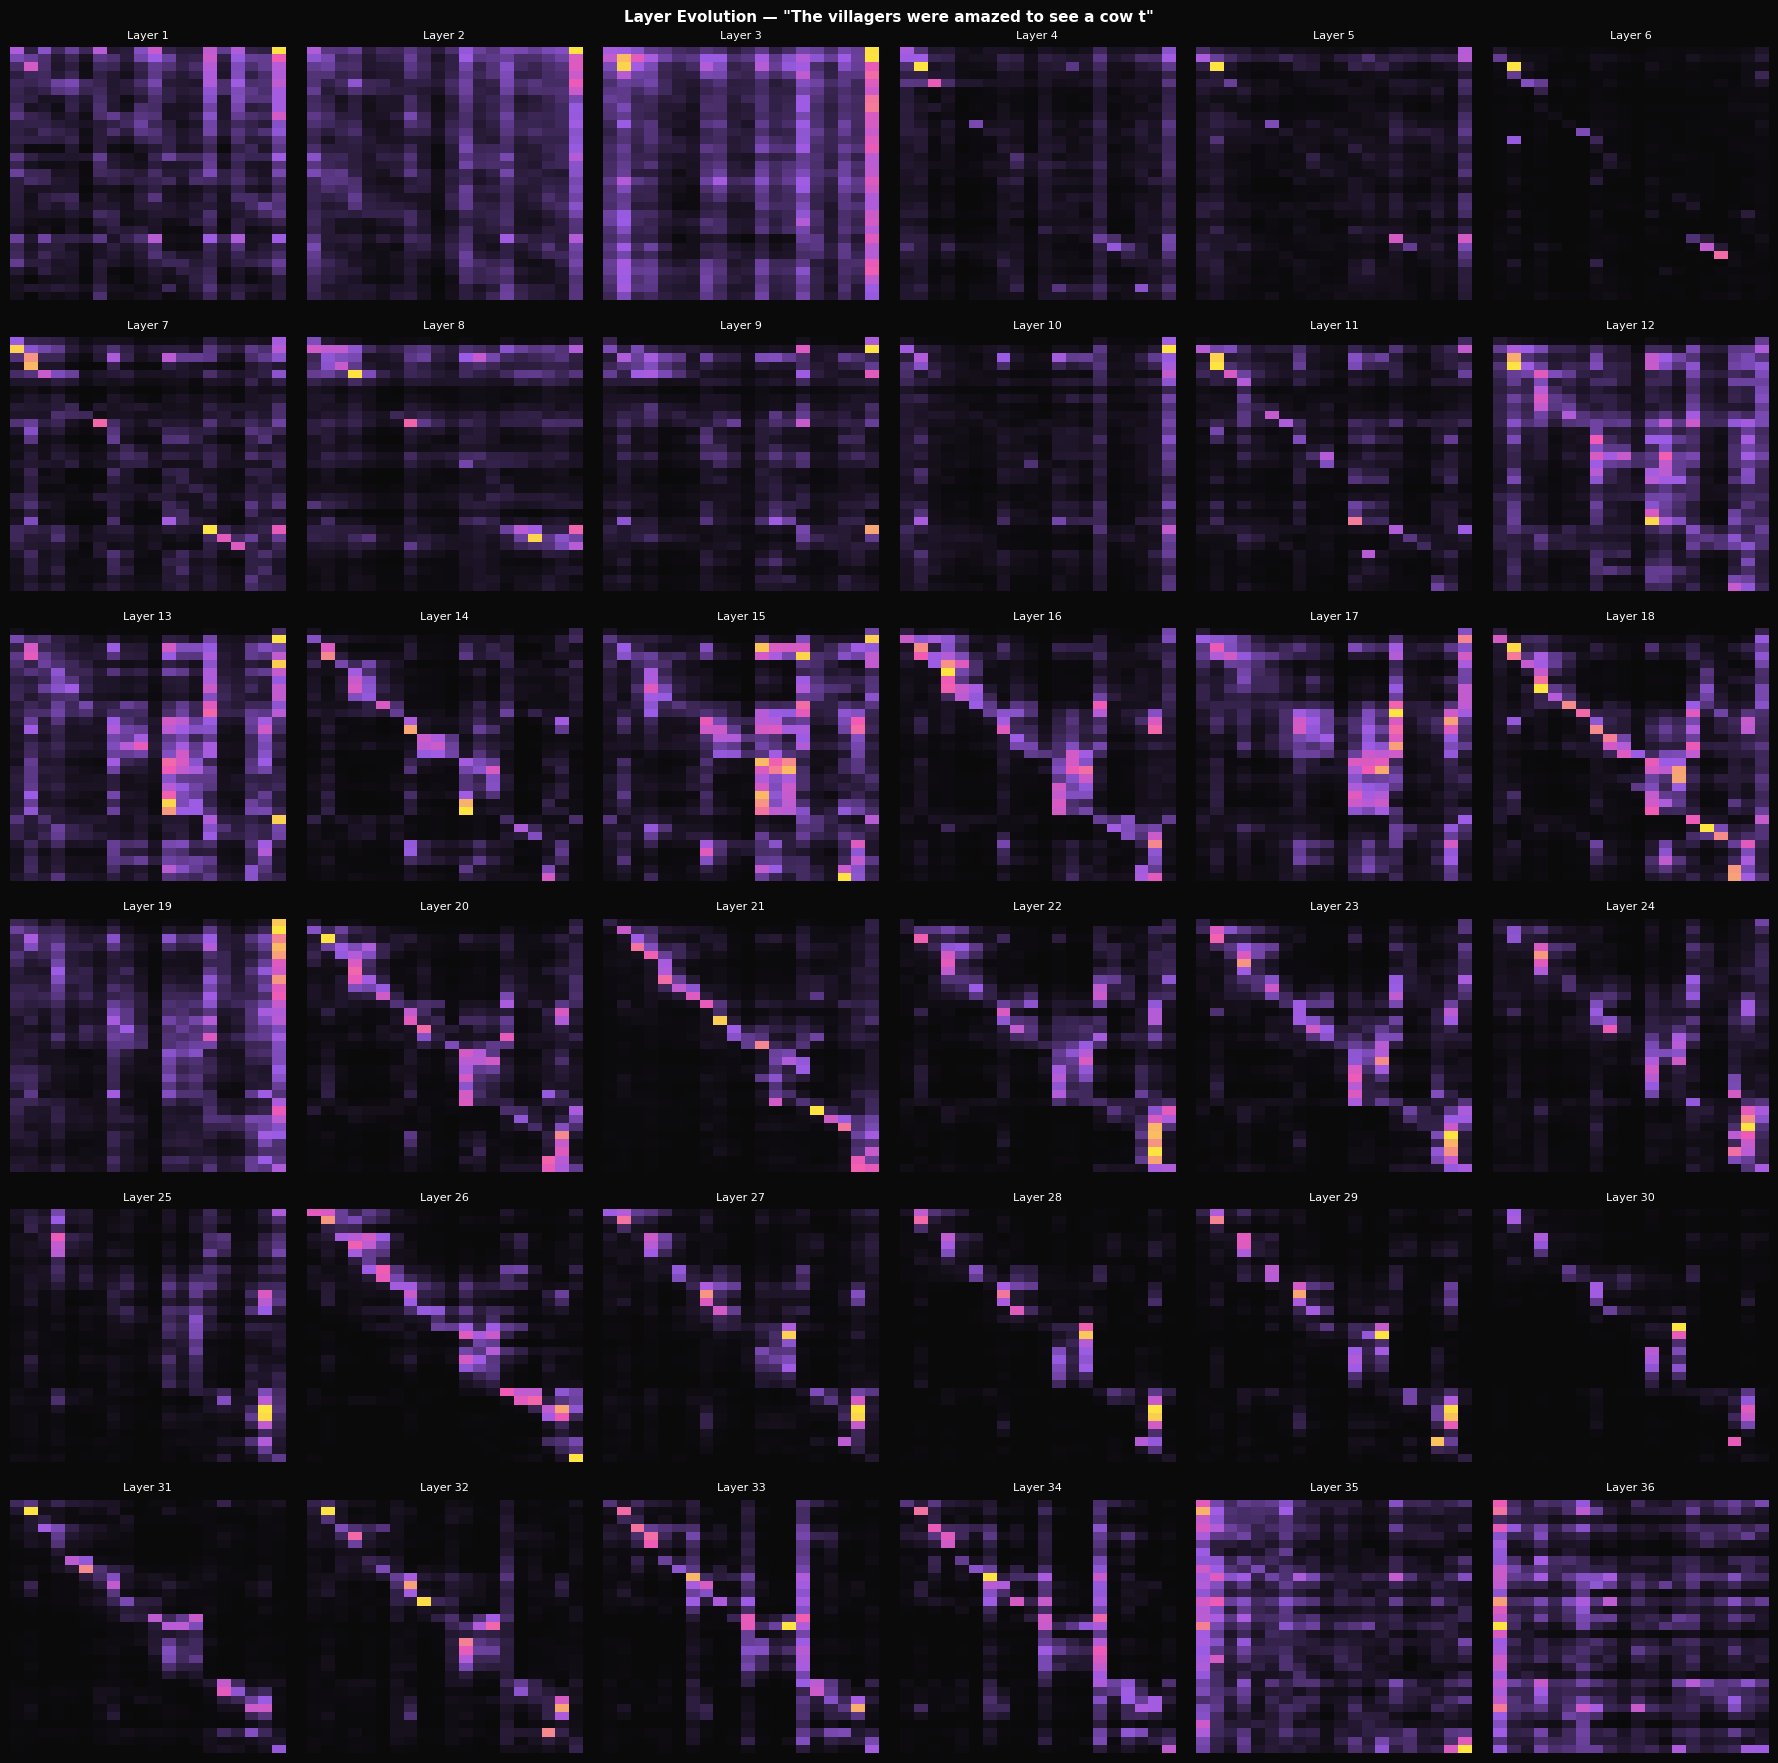

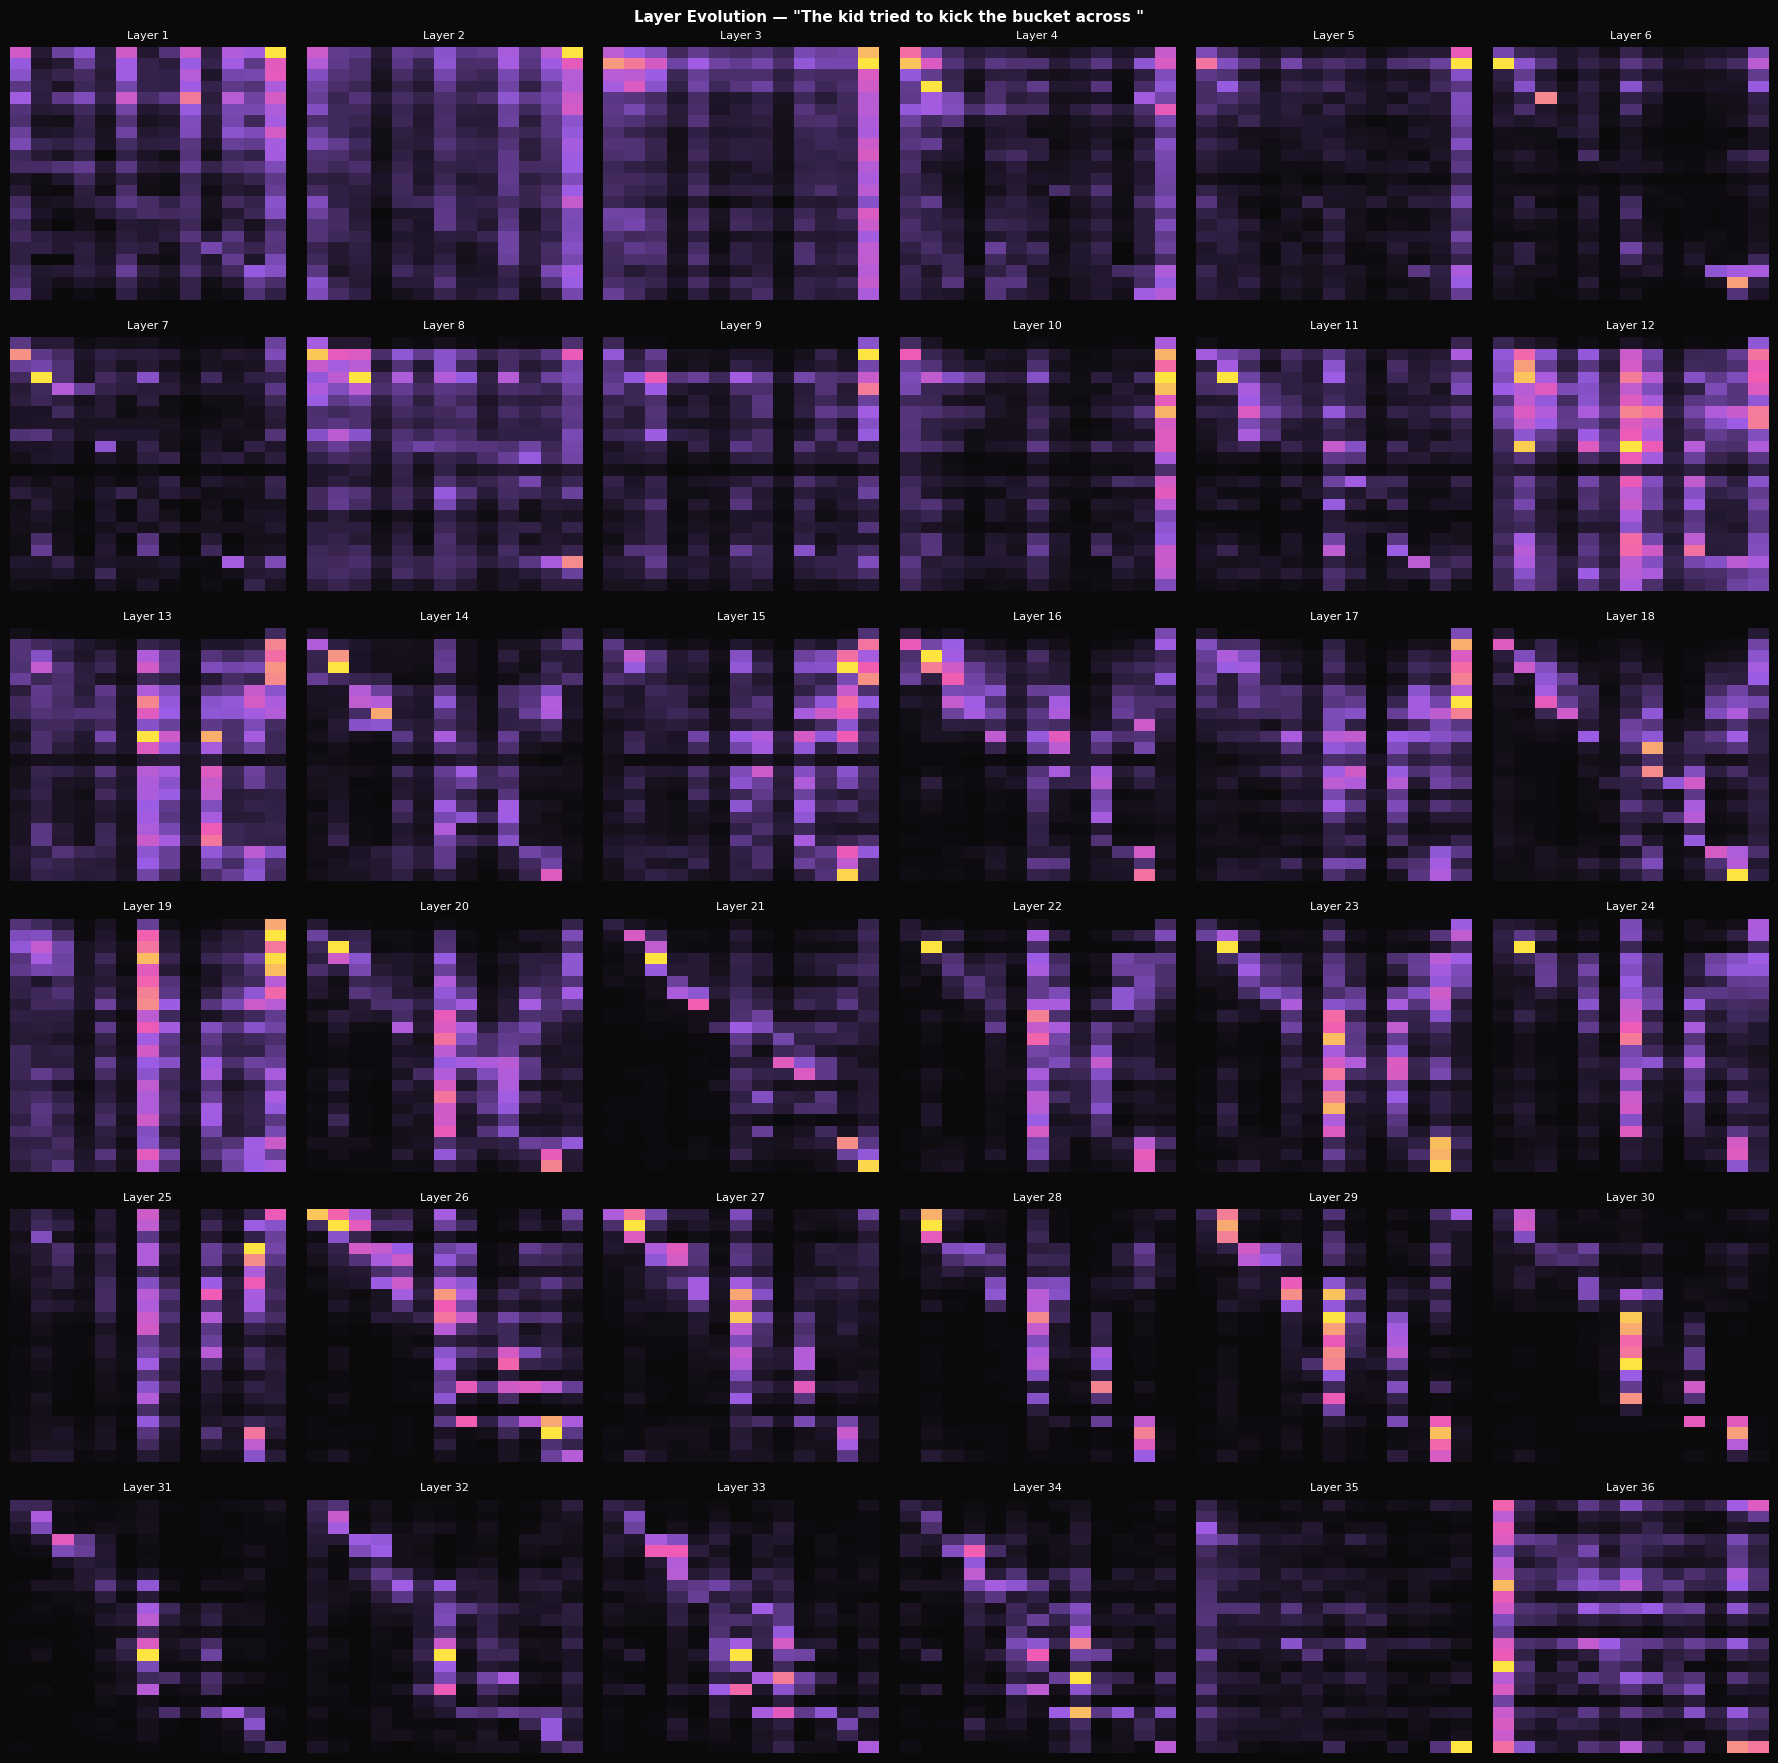

In [73]:
for i, case in enumerate(results):
    plot_layer_evolution(
        case["all_layers"], case["src_tok"], case["tgt_tok"],
        f"\"{case['text'][:40]}\""
    )

In [80]:
test_cases = [
    {"text": "Il ne cherche même pas à trouver un travail, il a vraiment un poil dans la main.", "src": "French", "tgt": "English"},
    {"text": "She spilled the beans about the surprise party.", "src": "English", "tgt": "French"},
    {"text": "The host told a funny joke at the start of the meeting to break the ice.", "src": "English", "tgt": "French"},
    {"text": "The test was a piece of cake; I finished it very quickly.", "src": "English", "tgt": "French"},
]

In [81]:
results = []

for case in test_cases:
    print(f"{case['text']}")
    translation, attn_slice, src_tok, tgt_tok, full_attn, full_tok, all_layers = \
        translate_with_attention(case["text"], case["src"], case["tgt"])
    case.update({
        "translation": translation,
        "attn_slice":  attn_slice,
        "src_tok":     src_tok,
        "tgt_tok":     tgt_tok,
        "full_attn":   full_attn,
        "full_tok":    full_tok,
        "all_layers":  all_layers,
    })
    print(f"  → {translation}\n")
    results.append(case)

Il ne cherche même pas à trouver un travail, il a vraiment un poil dans la main.
  → He even tries not to find a job, he really has a chip on his shoulder.

She spilled the beans about the surprise party.
  → Elle a laissé tomber le vinaigre concernant le pot de départ.

The host told a funny joke at the start of the meeting to break the ice.
  → Le hôte a raconté une blague drôle au début de la réunion pour dégeler la situation.

The test was a piece of cake; I finished it very quickly.
  → L'examen a été une pièce de gâteau ; j'en suis fini très vite.



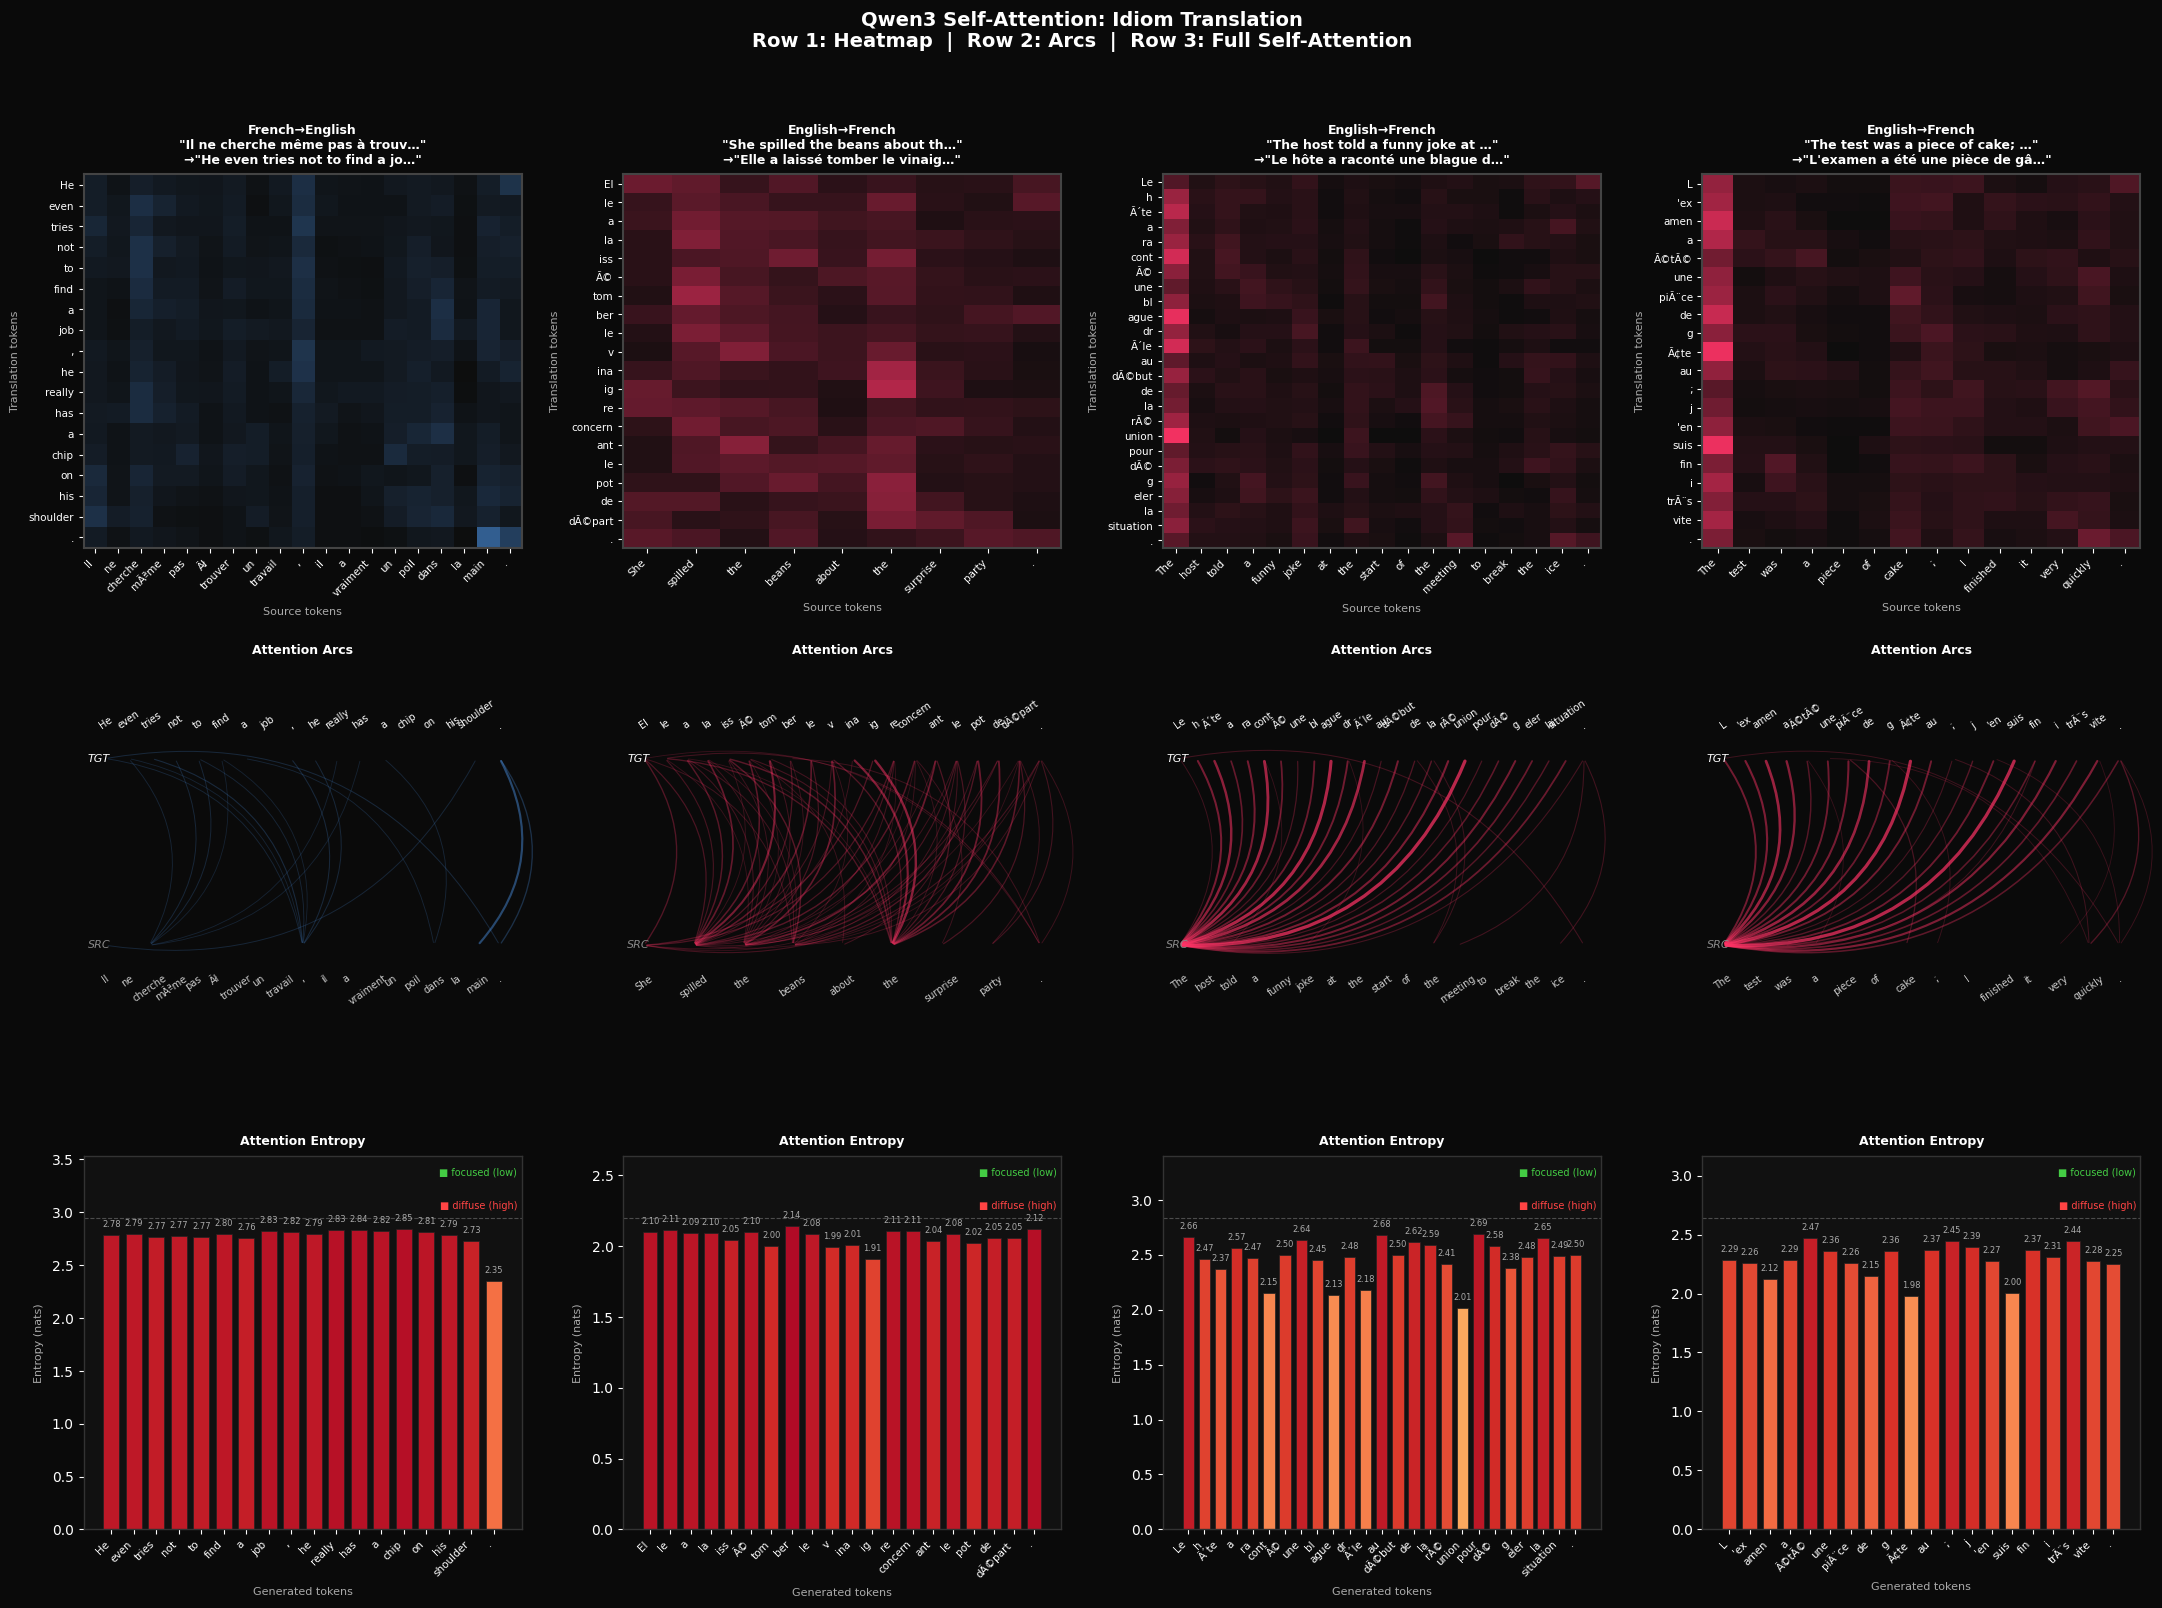

In [82]:
plt.rcParams.update({
    "text.color": "white", "axes.labelcolor": "white",
    "xtick.color": "white", "ytick.color": "white",
    "figure.facecolor": "#0a0a0a", "axes.facecolor": "#111111",
})

n = len(results)
fig, axes = plt.subplots(3, n, figsize=(5.5 * n, 16), facecolor="#0a0a0a")

fig.suptitle(
    "Qwen3 Self-Attention: Idiom Translation\n"
    "Row 1: Heatmap  |  Row 2: Arcs  |  Row 3: Full Self-Attention",
    fontsize=14, color="white", fontweight="bold", y=1.01
)

for col, case in enumerate(results):
    cmap  = cmap_en if case["src"] == "English" else cmap_fr
    color = "#ff3366" if case["src"] == "English" else "#4a90e2"
    short_src = case["text"][:30] + ("…" if len(case["text"]) > 30 else "")
    short_tgt = case["translation"][:30] + ("…" if len(case["translation"]) > 30 else "")
    title = f"{case['src']}→{case['tgt']}\n\"{short_src}\"\n→\"{short_tgt}\""

    plot_heatmap(case["attn_slice"], case["src_tok"], case["tgt_tok"],
                 title, axes[0][col], cmap)
    plot_arcs(case["attn_slice"], case["src_tok"], case["tgt_tok"],
              "Attention Arcs", axes[1][col], color)
    plot_entropy_bars(case["attn_slice"], case["tgt_tok"],
                      "Attention Entropy", axes[2][col], color)

plt.tight_layout(pad=2.0)
plt.show()